In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# set visual theme
sns.set_theme(style = "whitegrid")

**1. Loading a Dataset**

In [5]:
df = sns.load_dataset("tips")

In [7]:
df.head()
df.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


**Measure of Central Tendency**

In [8]:
col = df["total_bill"]

In [ ]:
print(col)

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 244, dtype: float64


13.42
Mean of total Bill: $19.79
Median of total Bill: $17.80
Mode of total Bill: $13.42


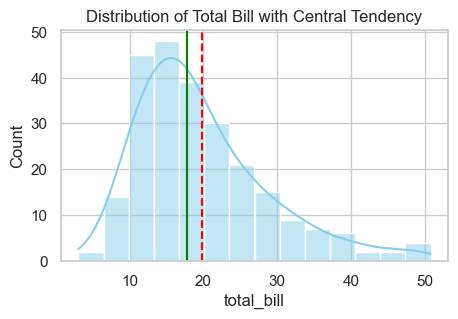

In [24]:
mean_val = np.mean(col)
median_val = np.median(col)
mode_val = col.mode()[0]
print(mode_val)

print(f"Mean of total Bill: ${mean_val:.2f}")
print(f"Median of total Bill: ${median_val:.2f}")
print(f"Mode of total Bill: ${mode_val:.2f}")

plt.figure(figsize=(5,3))
sns.histplot(col, kde=True, color = "skyblue")
plt.axvline(mean_val, color = "red",linestyle='--',label = f"Mean: {mean_val:.2f}")
plt.axvline(median_val, color = "green",linestyle='-',label = f"Median: {median_val:.2f}")
plt.legend
plt.title("Distribution of Total Bill with Central Tendency")
plt.show()

**Measure of Spread**

Spread tells us how scattered the data is around the center.

In [36]:
#Range
data_range = col.max() - col.min()

#Variance
variance = np.var(col)

#Standard Deviation
std_dev = np.std(col)

#IQR - Inter Quartile Range

Q1 = np.percentile(col,25)
Q3 = np.percentile(col,75)
iqr = Q3 - Q1

print(f"Range:{data_range:.2f}")
print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"IQR: {iqr:.2f}")

Range:47.74
Variance: 78.93
Standard Deviation: 8.88
IQR: 10.78


**Summary Statistics(df.describe)**

In [37]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


---

**6. Data Distribution and Skewness**

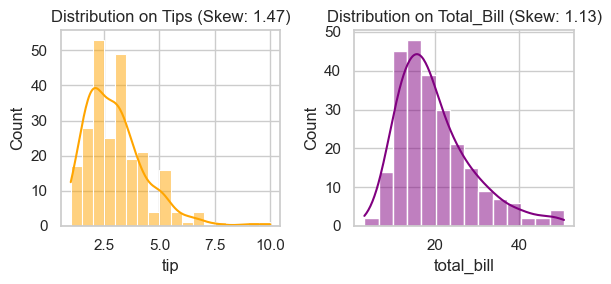

Interpretation
Skewness = 0: Perfetly Normal
Skewness > 0: Right Skewed
Skewness < 0: Left Skewed


In [39]:
plt.figure(figsize=(6,3))

#Plot 1 - Tip Distribution
plt.subplot(1,2,1)
sns.histplot(df["tip"],kde=True,color="orange")
plt.title(f"Distribution on Tips (Skew: {df["tip"].skew():.2f})")

#Plot 2 - Total Bill Distribution
plt.subplot(1,2,2)
sns.histplot(df["total_bill"],kde=True,color="purple")
plt.title(f"Distribution on Total_Bill (Skew: {df["total_bill"].skew():.2f})")

plt.tight_layout()
plt.show()

print("Interpretation")
print("Skewness = 0: Perfetly Normal")
print("Skewness > 0: Right Skewed")
print("Skewness < 0: Left Skewed")

**7.Outlier Detection**

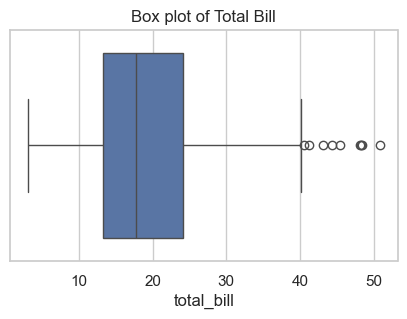

Lower Bound is:-2.82
Upper Bound is:40.30
Number of Outliers: 9


In [44]:
#1. Visual Method

plt.figure(figsize=(5,3))
sns.boxplot(x = df["total_bill"])
plt.title("Box plot of Total Bill")
plt.show()

Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound is:{lower_bound:.2f}")
print(f"Upper Bound is:{upper_bound:.2f}")

outliers = df[(df["total_bill"] < lower_bound) | (df["total_bill"] > upper_bound)]
print("Number of Outliers:",len(outliers))

**8. Correlation Analysis**

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


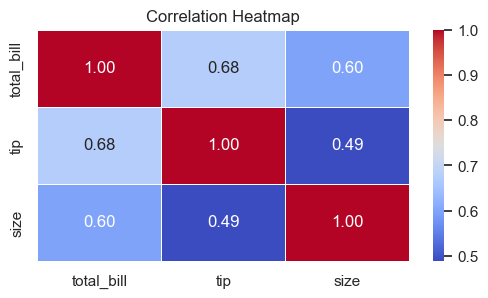


 Correlation between Total Bill and Tip: 0.6757341092113648


In [48]:
numerical_df = df.select_dtypes(include =[np.number])
corr_matrix = numerical_df.corr()

print(corr_matrix)

plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix,annot = True,cmap = "coolwarm",fmt = '.2f',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

print("\n Correlation between Total Bill and Tip:",end = " ")
print(corr_matrix.loc['total_bill','tip'])